# Лабораторная работа №3. Градиентный бустинг

В ноутбуке выполняется эксперимент по собственной реализации градиентного бустинга для бинарной классификации и сравнение с `sklearn.ensemble.GradientBoostingClassifier`.

## План эксперимента

1. Загрузить Breast Cancer Wisconsin (Diagnostic).
2. Обучить собственный `BinaryGradientBoostingClassifier`.
3. Сравнить качество, log loss и время обучения с `sklearn`.
4. Провести 5-fold кросс-валидацию.
5. Сохранить метрики и вспомогательные артефакты.

In [9]:
from pathlib import Path
import sys

import pandas as pd

LAB_DIR = Path.cwd()
if not (LAB_DIR / "source").exists():
    LAB_DIR = Path("students/mukhomediarova-ar/lab3").resolve()

SOURCE_DIR = LAB_DIR / "source"
ARTIFACTS_DIR = LAB_DIR / "artifacts"
sys.path.insert(0, str(SOURCE_DIR))

from data import make_splits
from main import MODEL_PARAMS, run_experiment

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

LAB_DIR

PosixPath('/Users/alinamukhomediarova/Documents/Study/ITMO/Алгоритмы МО/amo-spring-26/students/mukhomediarova-ar/lab3')

In [10]:
data = make_splits()

dataset_info = pd.DataFrame(
    [
        {"property": "dataset", "value": data.source_name},
        {"property": "train objects", "value": len(data.X_train)},
        {"property": "test objects", "value": len(data.X_test)},
        {"property": "features", "value": len(data.feature_names)},
        {"property": "classes", "value": ", ".join(data.target_names)},
    ]
)
dataset_info

,property,value
0,dataset,"Breast Cancer Wisconsin (Diagnostic), sklearn...."
1,train objects,455
2,test objects,114
3,features,30
4,classes,"malignant, benign"


In [11]:
MODEL_PARAMS

{'n_estimators': 120,
 'learning_rate': 0.08,
 'max_depth': 3,
 'min_samples_leaf': 3,
 'subsample': 0.9,
 'random_state': 42}

## Запуск эксперимента

Функция `run_experiment()` обучает обе модели, запускает кросс-валидацию и сохраняет CSV/JSON артефакты в `artifacts/`.

In [12]:
summary = run_experiment()
summary["sizes"]

{'train': 455, 'test': 114, 'features': 30}

In [13]:
metrics = pd.read_csv(ARTIFACTS_DIR / "metrics.csv")
metrics

,model,accuracy,precision,recall,f1,roc_auc,log_loss,train_time_seconds
0,Custom Gradient Boosting,0.9561,0.9467,0.9861,0.966,0.9931,0.1073,0.3788
1,sklearn GradientBoostingClassifier,0.9561,0.9467,0.9861,0.966,0.9927,0.1029,0.3276


In [14]:
cv_summary = pd.read_csv(ARTIFACTS_DIR / "cv_summary.csv")
cv_summary

,model,accuracy_mean,accuracy_std,roc_auc_mean,log_loss_mean,fit_time_mean_seconds
0,Custom Gradient Boosting,0.9604,0.0228,0.9936,0.1081,0.3163
1,sklearn GradientBoostingClassifier,0.9714,0.0200,0.9933,0.1087,0.3964


In [15]:
feature_importance = pd.read_csv(ARTIFACTS_DIR / "feature_importance.csv")
feature_importance.head(10)

,feature,custom_importance,sklearn_importance
0,worst concave points,0.1261,0.2376
1,worst perimeter,0.1114,0.2673
2,worst area,0.0717,0.0263
3,worst radius,0.0666,0.1753
4,mean concave points,0.0618,0.1611
5,worst texture,0.0589,0.0411
6,mean compactness,0.0555,0.0018
7,area error,0.0458,0.0125
8,mean texture,0.0442,0.0135
9,worst smoothness,0.0383,0.0051


In [16]:
loss_curve = pd.read_csv(ARTIFACTS_DIR / "loss_curve.csv")
loss_curve.groupby("model").tail(5)

,model,iteration,test_log_loss
115,Custom Gradient Boosting,116,0.1077
116,Custom Gradient Boosting,117,0.1074
117,Custom Gradient Boosting,118,0.1080
118,Custom Gradient Boosting,119,0.1065
119,Custom Gradient Boosting,120,0.1073
235,sklearn GradientBoostingClassifier,116,0.1030
236,sklearn GradientBoostingClassifier,117,0.1020
237,sklearn GradientBoostingClassifier,118,0.1021
238,sklearn GradientBoostingClassifier,119,0.1042
239,sklearn GradientBoostingClassifier,120,0.1029


## Визуализации

Ниже показаны графики, сохранённые экспериментом в папку `images/`.

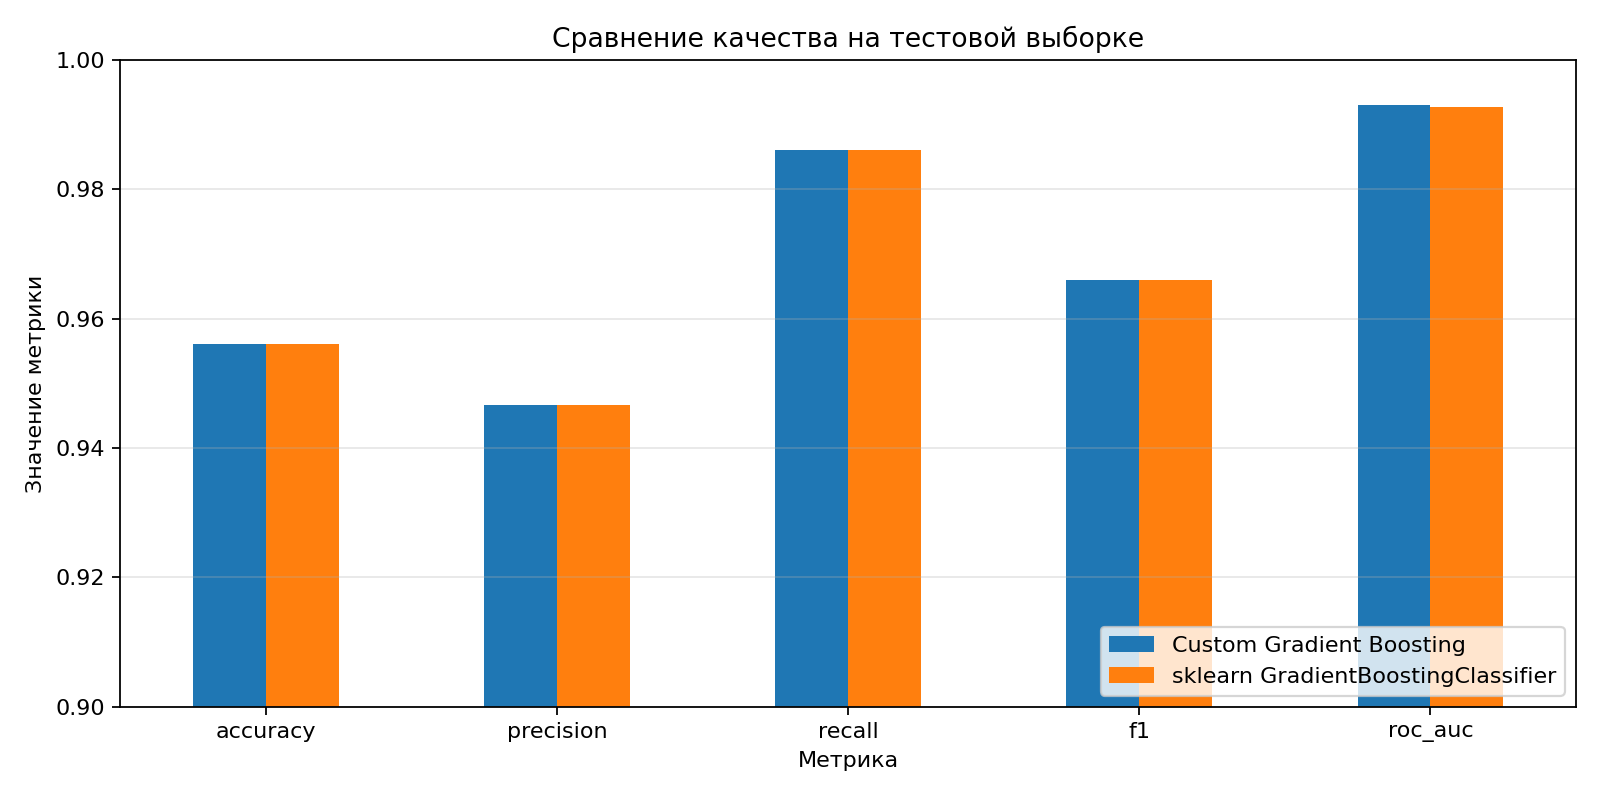

In [17]:
from IPython.display import Image, display

display(Image(filename=str(LAB_DIR / "images" / "metrics_comparison.png")))

**Вывод.** По основным классификационным метрикам модели совпадают: accuracy, precision, recall и F1 одинаковые. ROC AUC собственной реализации немного выше, но различие минимальное, поэтому на тестовой выборке качество можно считать сопоставимым.

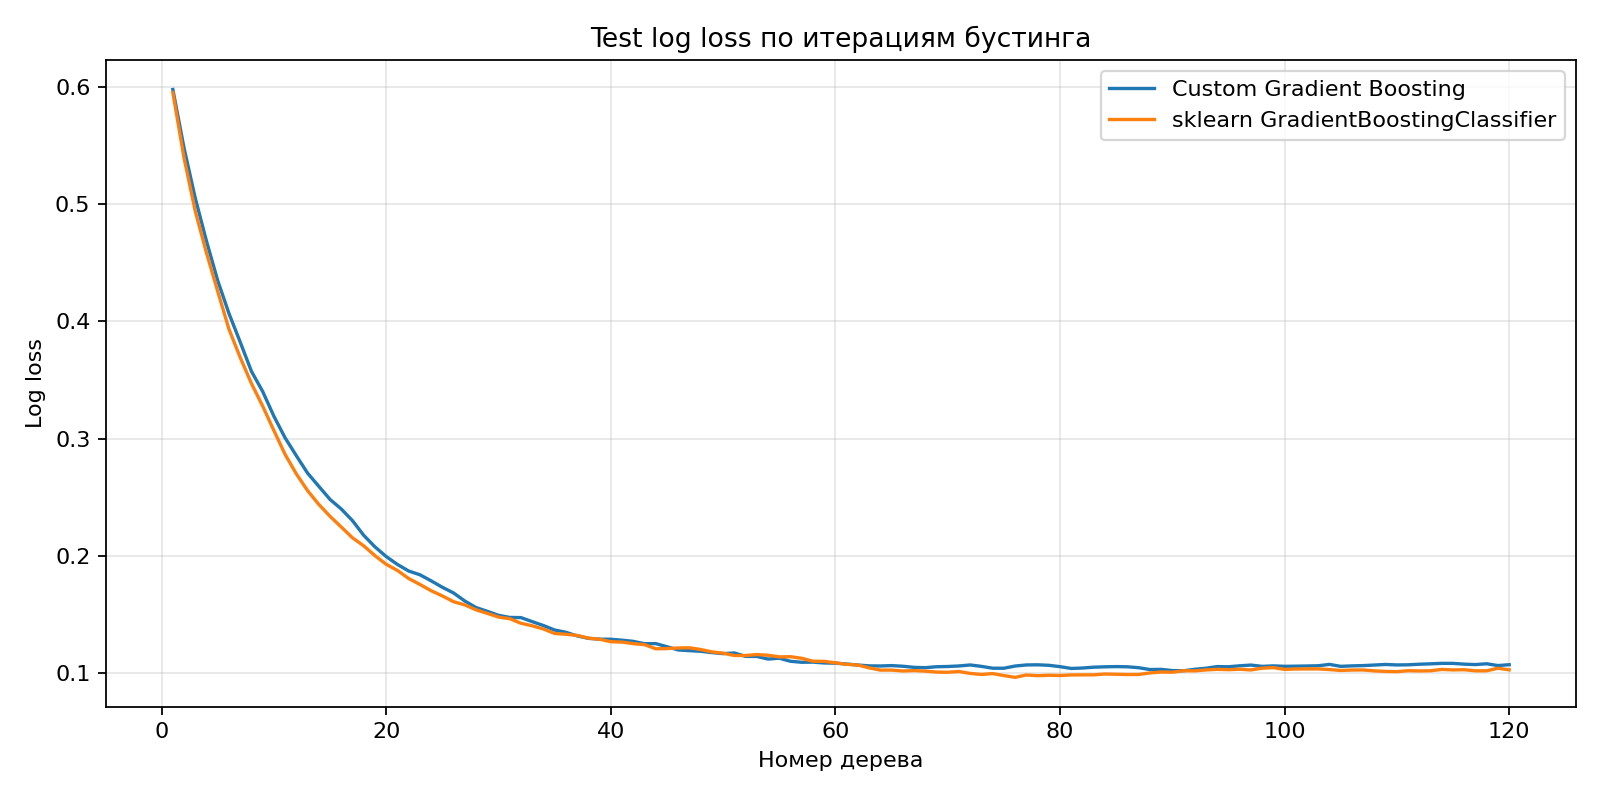

In [18]:
display(Image(filename=str(LAB_DIR / "images" / "loss_curve.png")))

**Вывод.** Log loss быстро снижается на первых итерациях, после чего выходит на плато. Это подтверждает, что бустинг последовательно улучшает вероятностные прогнозы; заметного роста ошибки к концу обучения нет.

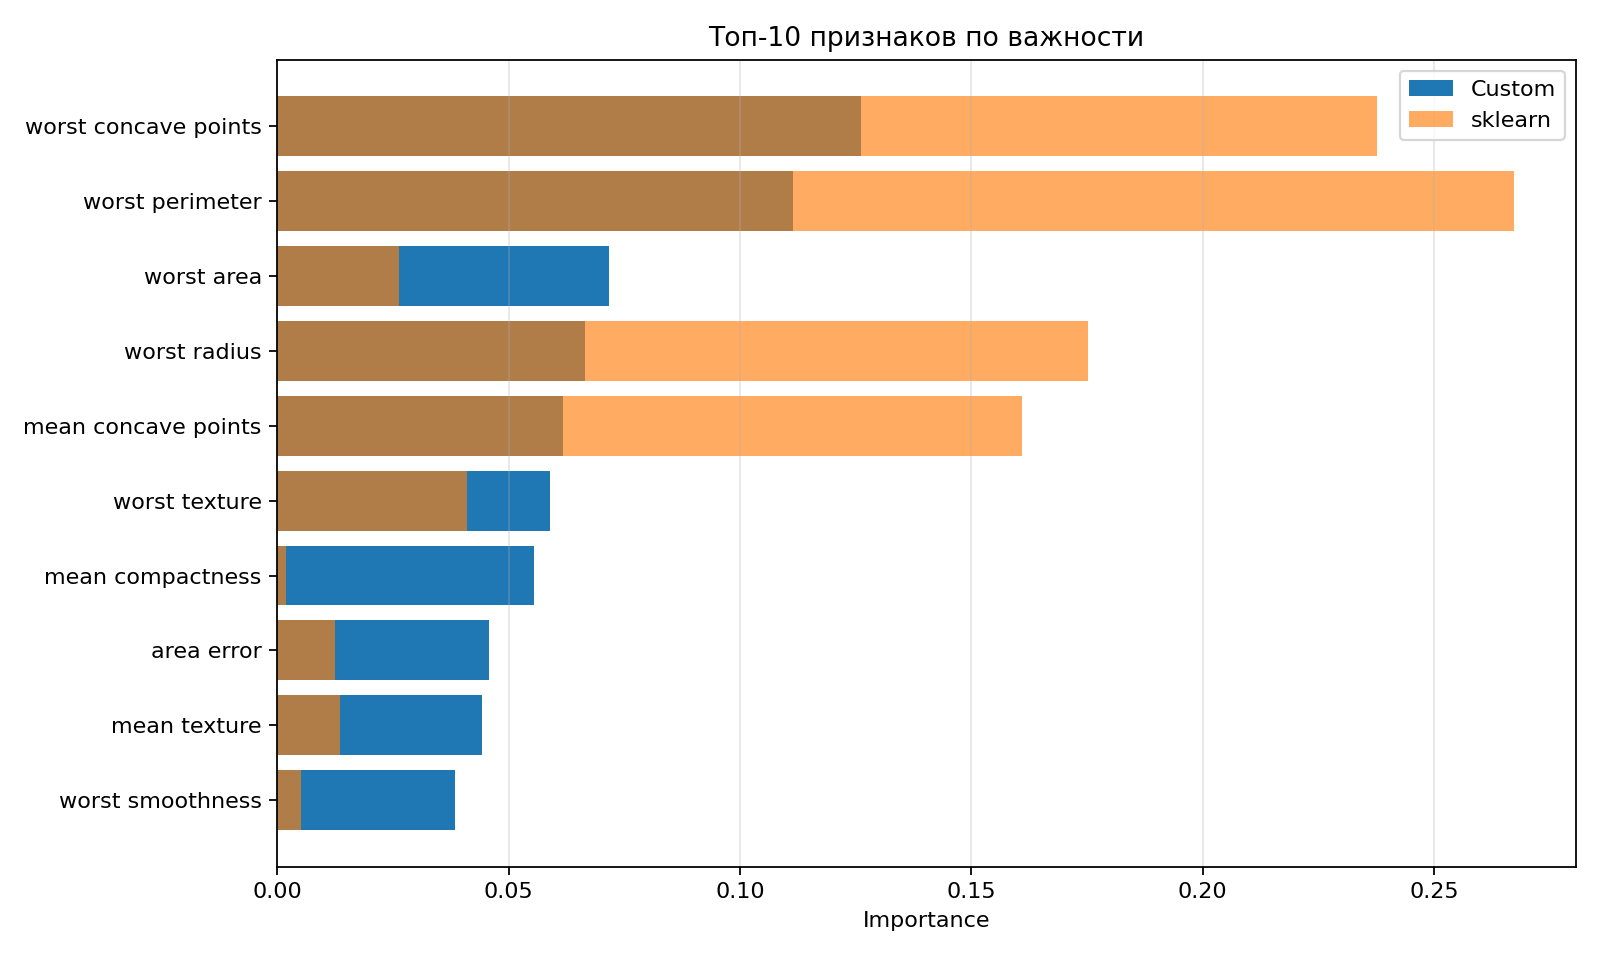

In [19]:
display(Image(filename=str(LAB_DIR / "images" / "feature_importance.png")))

**Вывод.** Наиболее важные признаки связаны с худшими значениями радиуса, периметра, площади и вогнутых точек опухоли. Абсолютные веса у custom и sklearn различаются, но верхняя группа признаков близка и хорошо интерпретируется для выбранного датасета.

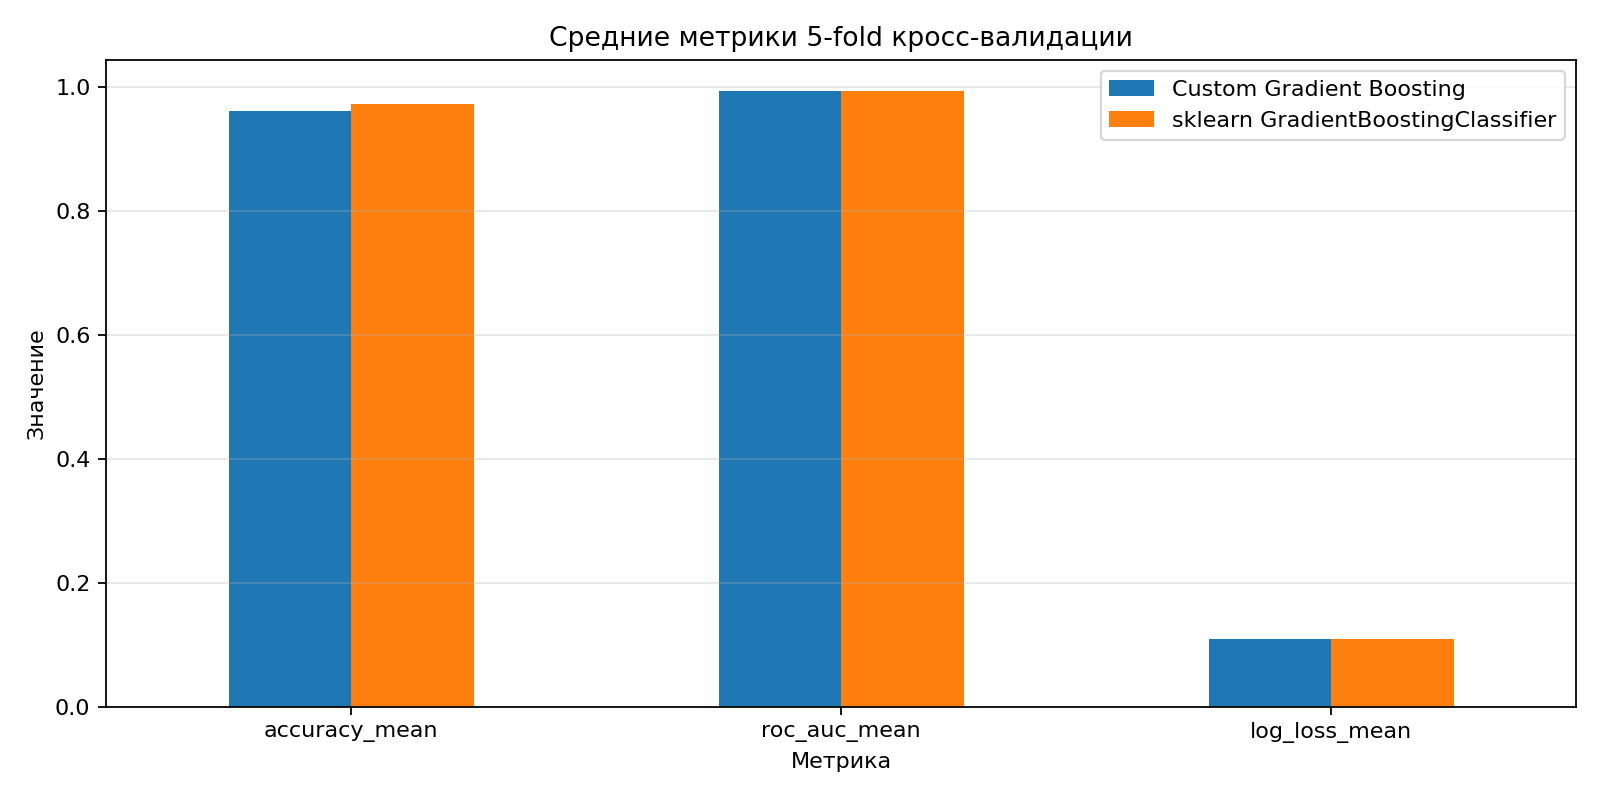

In [20]:
display(Image(filename=str(LAB_DIR / "images" / "cv_summary.png")))

**Вывод.** На кросс-валидации `sklearn` показывает более высокую среднюю accuracy и немного меньшее время обучения. При этом ROC AUC и log loss остаются практически на том же уровне, поэтому собственная реализация корректно воспроизводит основное поведение градиентного бустинга.

## Вывод

Собственная реализация градиентного бустинга показывает качество, близкое к эталонному `GradientBoostingClassifier`: на тестовой выборке совпадают accuracy, precision, recall и F1, а ROC AUC отличается незначительно. По средней accuracy на кросс-валидации `sklearn` немного лучше и быстрее, что ожидаемо для оптимизированной библиотечной реализации.